<a href="https://colab.research.google.com/github/anupmu/passiontodata/blob/main/Medical%20Assistant%20Bonsense%20AI%20with%20Web%20Interface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
model = YOLO("yolov8n.pt")

In [7]:
results = model.predict(source=image_path, save=True)


image 1/1 /content/cebdb327a865ed1352d5545f51dcd0_big_gallery.jpg: 640x448 1 vase, 373.4ms
Speed: 16.1ms preprocess, 373.4ms inference, 46.0ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict


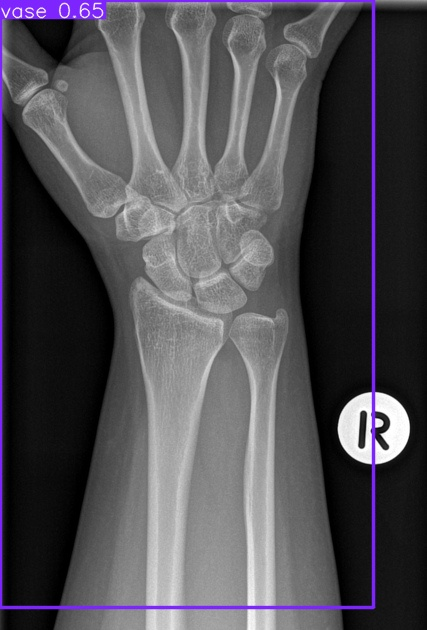

In [8]:
from IPython.display import Image, display

display(Image(filename='runs/detect/predict/' + image_path))

In [9]:
model = YOLO("yolov8n.pt")

In [12]:
from google.colab import files
uploaded = files.upload()

Saving best.pt to best.pt


In [13]:
from ultralytics import YOLO

model = YOLO("best.pt")

In [14]:
results = model.predict(source=image_path, conf=0.10, iou=0.45, imgsz=640, save=True)


image 1/1 /content/cebdb327a865ed1352d5545f51dcd0_big_gallery.jpg: 640x448 1 fractured, 138.3ms
Speed: 3.2ms preprocess, 138.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict-2


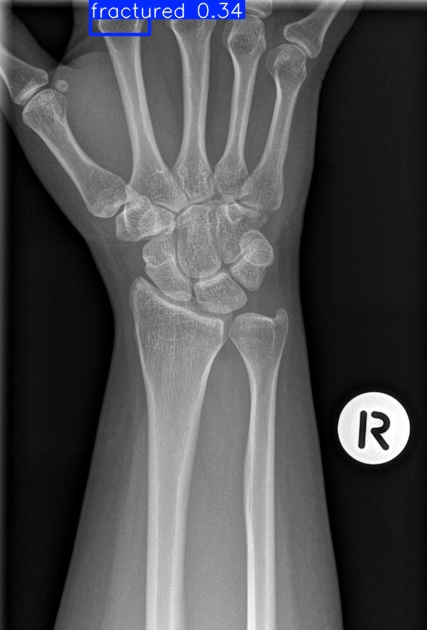

In [15]:
from IPython.display import Image, display
import os

output_folder = results[0].save_dir
output_image_path = os.path.join(output_folder, image_path)

display(Image(filename=output_image_path))

In [16]:
!pip install transformers accelerate sentencepiece bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.8 MB/s eta 0:00:00


In [17]:
!pip install transformers accelerate sentencepiece bitsandbytes huggingface_hub

In [18]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [19]:
from transformers import AutoProcessor

In [20]:
model_id = "microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

In [21]:
processor = AutoProcessor.from_pretrained(model_id)

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [26]:
from transformers import AutoModel
import torch

In [27]:
!pip install -U transformers accelerate bitsandbytes huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 35.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [1]:
import torch
from transformers import pipeline

In [2]:
medgemma_id = "google/medgemma-1.5-4b-it"

pipe = pipeline(
    "image-text-to-text",
    model=medgemma_id,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [4]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print(image_path)

Saving cebdb327a865ed1352d5545f51dcd0_big_gallery.jpg to cebdb327a865ed1352d5545f51dcd0_big_gallery (1).jpg
cebdb327a865ed1352d5545f51dcd0_big_gallery (1).jpg


In [5]:
confidence = 34.0

if confidence < 40:
    severity = "Low Risk"
elif confidence < 70:
    severity = "Moderate Risk"
else:
    severity = "High Risk"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "path": image_path},
            {
                "type": "text",
                "text": f"""
Analyze this X-ray image for educational project demonstration.

A YOLO fracture detection model marked a suspected fracture region.
Detection confidence: {confidence}%
Severity level: {severity}

Generate a short radiologist-style report with:
1. Findings
2. Impression
3. Severity
4. Recommendation

Mention that this is AI-assisted output and final diagnosis requires radiologist confirmation.
"""
            }
        ]
    }
]

output = pipe(text=messages, max_new_tokens=250)
print(output[0]["generated_text"][-1]["content"])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FINDINGS:
The X-ray shows a right wrist. There is a suspected fracture in the distal radius, near the wrist joint. The fracture appears to be a non-displaced fracture.

IMPRESSION:
Suspected non-displaced fracture of the distal radius.

SEVERITY:
Low Risk

RECOMMENDATION:
Further evaluation by a radiologist is recommended for confirmation and further management. This is AI-assisted output and final diagnosis requires radiologist confirmation.



In [15]:
!pip install gradio

In [16]:
import gradio as gr
import traceback
from PIL import Image
import numpy as np

In [18]:
from ultralytics import YOLO

In [19]:
model = YOLO("best.pt")

In [20]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [21]:
print(pipe)

ImageTextToTextPipeline: {'model': 'Gemma3ForConditionalGeneration', 'dtype': 'bfloat16', 'device': 'cpu', 'input_modalities': ('image', 'text'), 'output_modalities': ('text',)}


In [22]:
print(pipe)

ImageTextToTextPipeline: {'model': 'Gemma3ForConditionalGeneration', 'dtype': 'bfloat16', 'device': 'cpu', 'input_modalities': ('image', 'text'), 'output_modalities': ('text',)}


In [23]:
import gradio as gr
import traceback
from PIL import Image

def analyze_xray(input_image):
    try:
        image_path = "gradio_uploaded_xray.png"
        input_image = input_image.convert("RGB")
        input_image.save(image_path)

        results = model.predict(
            source=image_path,
            conf=0.10,
            iou=0.45,
            imgsz=640,
            verbose=False
        )

        result = results[0]
        marked_image = result.plot()
        marked_image = marked_image[:, :, ::-1]

        boxes = result.boxes

        if len(boxes) == 0:
            confidence_text = "No fracture detected"
            severity = "Normal"
            yolo_finding = "No fracture region was detected by YOLO."
        else:
            confidence = float(boxes[0].conf[0]) * 100
            confidence_text = f"{confidence:.2f}%"

            if confidence < 40:
                severity = "Low Risk"
            elif confidence < 70:
                severity = "Moderate Risk"
            else:
                severity = "High Risk"

            yolo_finding = f"YOLO detected a suspected fracture region with {confidence:.2f}% confidence."

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "path": image_path},
                    {
                        "type": "text",
                        "text": f"""
Analyze this X-ray image for educational project demonstration.

YOLO finding:
{yolo_finding}

Severity level:
{severity}

Generate a short radiologist-style report with:
1. Findings
2. Impression
3. Severity
4. Recommendation

Mention that this is AI-assisted output and final diagnosis requires radiologist confirmation.
"""
                    }
                ]
            }
        ]

        output = pipe(text=messages, max_new_tokens=250)
        report = output[0]["generated_text"][-1]["content"]

        return marked_image, confidence_text, severity, report

    except Exception:
        return None, "Error", "Error", traceback.format_exc()

In [24]:
app = gr.Interface(
    fn=analyze_xray,
    inputs=gr.Image(type="pil", label="Upload X-ray Image"),
    outputs=[
        gr.Image(type="numpy", label="Marked X-ray Image"),
        gr.Textbox(label="Confidence Score"),
        gr.Textbox(label="Severity"),
        gr.Textbox(label="MedGemma Radiology-style Report", lines=12)
    ],
    title="BoneSense AI",
    description="AI-assisted bone X-ray assessment using YOLO fracture detection and MedGemma report generation."
)

app.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://26f235e60b6731c24b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://26f235e60b6731c24b.gradio.live
